# Stock Price Predictor using Machine Learning

Initial imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf       # yahoo finance API from which we will get our data
import matplotlib.pyplot as plt     # Visualization

import torch        # Deep learning library
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler        # scale and...
from sklearn.metrics import root_mean_squared_error     # ... evaluation

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.125244  296.143492  293.992293  294.912936  59151200
2020-01-03  293.882965  295.004144  292.688877  292.743566  77709700
2020-01-06  295.004181  295.086214  292.014370  292.132872  55653900
2020-01-07  294.174652  294.912981  293.727989  294.438973  40496400
2020-01-08  295.742462  296.954771  294.119959  294.366059  68296000
...                ...         ...         ...         ...       ...
2026-09-04  770.190002  772.869995  769.000000  772.010010  34054200
2026-09-08  765.960022  769.700012  765.140015  769.070007  44746100
2026-09-09  762.400024  764.469971  760.940002  764.080017  32812400
2026-09-10  757.830017  760.109985  756.640015  758.030029  42740400
2026-09-11  764.289978  766.380005  763.599976  764.719971  45477300

[1682 rows x 5 columns]


<Axes: xlabel='Date'>

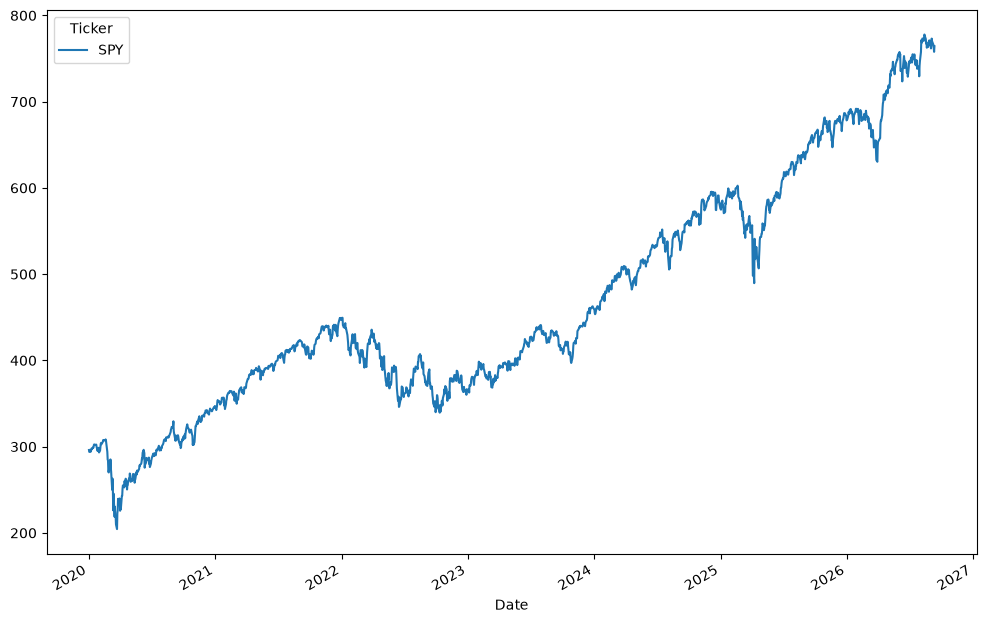

In [2]:
# Ideally, we want to use a CUDA supported GPU, but if unavailable, we can use any CPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Next we want to take our ticker, in this case SPY, and load the ticker data into a dataframe starting from january of 2020
ticker = 'SPY'
df = yf.download(ticker, '2020-01-01')
print(df)

# Plotting the Close prices of SPY
df.Close.plot(figsize=(12, 8))

We've taken our data from the yfinance import, loaded it into a dataframe and plotted the points. Our plan is to cut 80% of that data to train our model, and use it to predict or test it against the last 20% or so.

In [10]:
# We will create a scaler object to standardize our data
scaler = StandardScaler()

# Remove the mean from our x and scaling to unit variance dividing by standard deviation
std_df = pd.DataFrame(scaler.fit_transform(df['Close']))
print(std_df)

             0
0    -1.280315
1    -1.297079
2    -1.288696
3    -1.294899
4    -1.283177
...        ...
1677  2.264076
1678  2.232451
1679  2.205834
1680  2.171666
1681  2.219964

[1682 rows x 1 columns]


In [ ]:
seq_length = 30
data = []

# Looking at 29 days and predicting the last day
for i in range(len(std_df) - seq_length):
    data.append(std_df[i:i+seq_length])

data = np.array(data)
print(data)

[[[-1.28031472]
  [-1.29707934]
  [-1.28869646]
  ...
  [-1.20950563]
  [-1.19478517]
  [-1.19723843]]

 [[-1.29707934]
  [-1.28869646]
  [-1.29489851]
  ...
  [-1.19478517]
  [-1.19723843]
  [-1.19355831]]

 [[-1.28869646]
  [-1.29489851]
  [-1.28317663]
  ...
  [-1.19723843]
  [-1.19355831]
  [-1.19948771]]

 ...

 [[ 2.04478776]
  [ 1.95955483]
  [ 2.05099347]
  ...
  [ 2.2863566 ]
  [ 2.26407649]
  [ 2.23245063]]

 [[ 1.95955483]
  [ 2.05099347]
  [ 2.0909187 ]
  ...
  [ 2.26407649]
  [ 2.23245063]
  [ 2.20583396]]

 [[ 2.05099347]
  [ 2.0909187 ]
  [ 2.17046934]
  ...
  [ 2.23245063]
  [ 2.20583396]
  [ 2.17166585]]]


Test/Train Split

We are interested in sequential prediction

In [ ]:
train_size = int(.8 * len(data))
x_train = torch.from_numpy(data[:train_size, :-1, :])
y_train = torch.from_numpy(data[:train_size, -1, :])
x_test = torch.from_numpy(data[train_size:, -1, :])
y_test = torch.from_numpy(data[train_size:, -1, :])
